# BiPlane Challenge

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "~/jobs/deploy/decode"
path = "~/git/decode"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [4]:
import decode
from decode.neuralfitter.train import setup_cfg
print(decode.__file__)


%config InlineBackend.figure_format='retina'

/Users/lucasmueller/git/decode/decode/__init__.py


In [5]:
path_out = "/Volumes/ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge"
path_out = Path(path_out)

# path_smap = "/mnt/t1ries/decode/fit/biplane_challenge/"
# path_smap = Path(path_smap)

path_scen = path_out / "scen_out.pkl"

In [6]:
scen_out = pd.read_pickle(path_scen)
scen_out

dataset  \
snr  density type  algorithm              
low  low     train DECODE     MT0_N2_LD   
             test  DECODE     MT3_N2_LD   
     high    train DECODE     MT0_N2_HD   
             test  DECODE     MT4_N2_HD   
high low     train DECODE     MT0_N1_LD   
             test  DECODE     MT1_N1_LD   
     high    train DECODE     MT0_N1_HD   
             test  DECODE     MT2_N1_HD   

                                                                      path_data  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                     path_frame  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                        path_em  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   

                                                                     path_model  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
high low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   

                                                                    path_em_out  
snr  density type  algorithm                                                     
low  low     train DECODE     /mnt/t1ries/users/Lucas/Manuscripts/plex/raw/b...  
             test  DECODE     /

In [10]:
path_em = "/Volumes/PRO-G40/temp/biplane_challenge/MT0_N1_LD_decode_fit_dens_filtered.h5"
em_out = decode.EmitterSet.load(path_em)

In [18]:
path_gt = "/Volumes/PRO-G40/decode_scratch/other/challenge/MT0_N1_LD/activations.csv"
data, *_ = decode.io.emitter.load_challenge(path_gt)

em_gt = decode.EmitterSet(**data, xy_unit="nm", px_size=[100., 100.])

In [19]:
print(em_gt)

EmitterSet
::num emitters: 24938
::xy unit: nm
::px size: tensor([100., 100.])
::frame range: 1 - 19996
::spanned volume: [2.0880000591278076, 3.1679999828338623, -667.5679931640625] - [6398.76416015625, 6398.546875, 634.8079833984375]
::photon range: 78.78299713134766 - 10576.8603515625


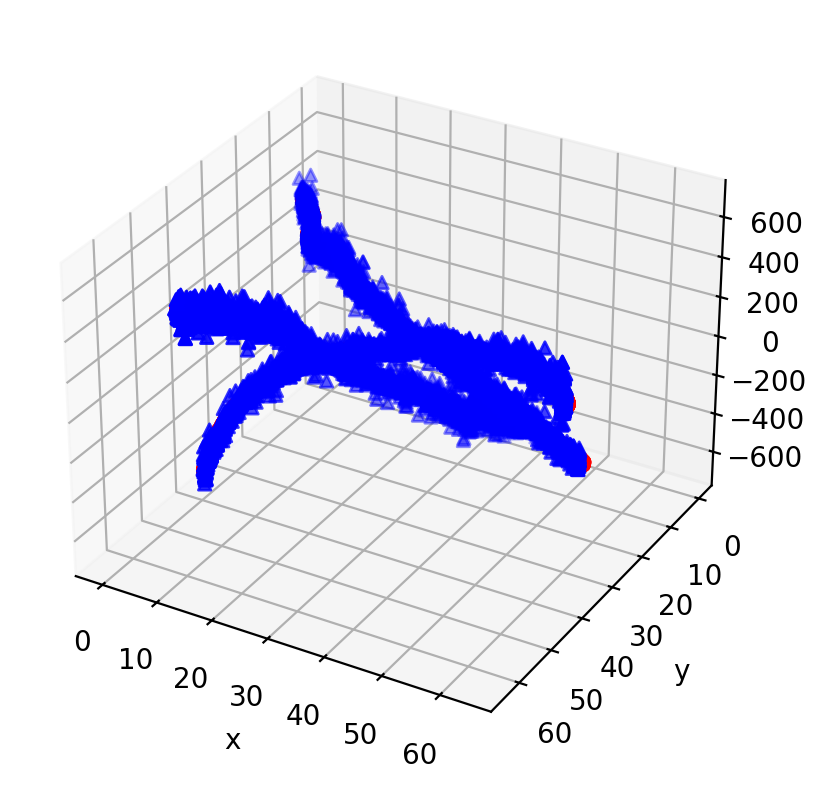

In [21]:
decode.plot.PlotCoordinates3D(pos_out=em_out.xyz_px, pos_tar=em_gt.xyz_px).plot()

In [23]:
pd.read_csv(path_gt)

,Ground-truth,frame,xnano,ynano,znano,intensity
0,1,9039,43.325,839.830,340.704,2473.663
1,2,9040,43.325,839.830,340.704,273.371
2,3,15342,39.005,850.199,331.856,3893.158
3,4,15343,39.005,850.199,331.856,1039.886
4,5,12283,56.375,868.420,333.775,526.689
...,...,...,...,...,...,...
24933,24934,9289,6391.218,3741.180,218.190,2763.591
24934,24935,9290,6391.218,3741.180,218.190,5425.503
24935,24936,9294,6391.218,3741.180,218.190,1020.940
24936,24937,9295,6391.218,3741.180,218.190,2147.715


In [26]:
def decodeh5_to_challenge_csv(path_em, path_out):
    em = decode.EmitterSet.load(path_em)
    em.id = torch.arange(len(em)) if em.id is None else em.id

    df = pd.DataFrame({
        "Ground-truth": em.id.tolist(),
        "frame": em.frame_ix.tolist(),
        "xnano": em.xyz_nm[:, 0].tolist(),
        "ynano": em.xyz_nm[:, 1].tolist(),
        "znano": em.xyz_nm[:, 2].tolist(),
        "intensity": em.phot.tolist(),
    })
    df.to_csv(path_out, index=False)

In [30]:
for p in path_out.glob("*dens_filtered*.h5"):
    decodeh5_to_challenge_csv(p, p.with_name(f"{p.stem[:10]}_decode_fit_challenge_standard.csv"))